In [2]:
!pip install -q xgboost pyarrow joblib

In [3]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [4]:
# Example:
# DATA_DIR = Path("/kaggle/input/my-btagging-parquets")

DATA_DIR = Path("/kaggle/input/datasets/tonnysoyyo/btag-dataset")
OUTPUT_DIR = Path("/kaggle/working/bdt_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_EFF = 0.70
RANDOM_STATE = 42

META_COLS = {
    "sample_label",
    "is_b",
    "root_file",
    "event_in_file",
    "jet_rank",
    "global_event_id",
}

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_DIR: /kaggle/input/datasets/tonnysoyyo/btag-dataset
OUTPUT_DIR: /kaggle/working/bdt_outputs


In [5]:
train = pd.read_parquet(DATA_DIR / "train_20menos.parquet")
val   = pd.read_parquet(DATA_DIR / "val_20menos.parquet")
test  = pd.read_parquet(DATA_DIR / "test_20menos.parquet")

print("Train shape:", train.shape)
print("Val shape:  ", val.shape)
print("Test shape: ", test.shape)

Train shape: (422101, 38)
Val shape:   (90537, 38)
Test shape:  (90306, 38)


In [6]:
print("Train class counts:")
print(train["sample_label"].value_counts())
print()

print("Val class counts:")
print(val["sample_label"].value_counts())
print()

print("Test class counts:")
print(test["sample_label"].value_counts())
print()

print("Binary counts in train:")
print(train["is_b"].value_counts())

Train class counts:
sample_label
uds    255436
b      166665
Name: count, dtype: int64

Val class counts:
sample_label
uds    54603
b      35934
Name: count, dtype: int64

Test class counts:
sample_label
uds    54695
b      35611
Name: count, dtype: int64

Binary counts in train:
is_b
0    255436
1    166665
Name: count, dtype: int64


In [7]:
feature_cols = [c for c in train.columns if c not in META_COLS]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 32
['jet_pt', 'jet_eta', 'jet_abs_eta', 'jet_mass', 'jet_ncharged', 'jet_nneutral', 'n_tracks_cone', 'track_pt_sum', 'track_pt_sum_over_jet_pt', 'avg_track_pt', 'std_track_pt', 'n_tracks_below_avg_pt', 'n_tracks_above_avg_pt', 'max_pt_ratio', 'min_pt_ratio', 'max_dr_ratio', 'min_dr_ratio', 'dr_max_pt', 'dr_min_pt', 'dr_max_dr', 'dr_min_dr', 'pt_difference', 'r50', 'r95', 'mean_abs_d0', 'max_abs_d0', 'std_abs_d0', 'mean_abs_dz', 'max_abs_dz', 'std_abs_dz', 'pt_weighted_abs_d0', 'pt_weighted_abs_dz']


In [8]:
for df in [train, val, test]:
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    df[feature_cols] = df[feature_cols].fillna(0.0)

X_train = train[feature_cols].astype(np.float32).values
y_train = train["is_b"].astype(np.int32).values

X_val = val[feature_cols].astype(np.float32).values
y_val = val["is_b"].astype(np.int32).values

X_test = test[feature_cols].astype(np.float32).values
y_test = test["is_b"].astype(np.int32).values

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (422101, 32)
X_val:   (90537, 32)
X_test:  (90306, 32)


In [9]:
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
scale_pos_weight = n_neg / max(n_pos, 1)

print("Number of positive jets (b):", n_pos)
print("Number of negative jets (non-b):", n_neg)
print("scale_pos_weight:", scale_pos_weight)

Number of positive jets (b): 166665
Number of negative jets (non-b): 255436
scale_pos_weight: 1.5326313263132632


In [10]:
def mistag_report(df: pd.DataFrame, scores: np.ndarray, target_eff: float = 0.70):
    y = df["is_b"].values
    score_b = scores[y == 1]
    threshold = np.quantile(score_b, 1.0 - target_eff)

    pred = scores >= threshold
    sample = df["sample_label"].values

    b_eff = float(np.mean(pred[y == 1]))
    c_mistag = float(np.mean(pred[sample == "c"])) if np.any(sample == "c") else np.nan

    light_mask = np.isin(sample, ["g", "uds"])
    light_mistag = float(np.mean(pred[light_mask])) if np.any(light_mask) else np.nan

    return {
        "threshold": float(threshold),
        "b_eff": b_eff,
        "c_mistag": c_mistag,
        "light_mistag": light_mistag,
        "c_rejection": (1.0 / c_mistag) if c_mistag > 0 else np.inf,
        "light_rejection": (1.0 / light_mistag) if light_mistag > 0 else np.inf,
    }

In [11]:
model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",   # good for Kaggle CPU
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)

[0]	validation_0-auc:0.85596	validation_1-auc:0.85498
[50]	validation_0-auc:0.86363	validation_1-auc:0.86129
[100]	validation_0-auc:0.86675	validation_1-auc:0.86359
[150]	validation_0-auc:0.86876	validation_1-auc:0.86463
[200]	validation_0-auc:0.87043	validation_1-auc:0.86530
[250]	validation_0-auc:0.87165	validation_1-auc:0.86559
[300]	validation_0-auc:0.87277	validation_1-auc:0.86577
[350]	validation_0-auc:0.87393	validation_1-auc:0.86597
[400]	validation_0-auc:0.87491	validation_1-auc:0.86604
[450]	validation_0-auc:0.87589	validation_1-auc:0.86607
[500]	validation_0-auc:0.87687	validation_1-auc:0.86612
[550]	validation_0-auc:0.87777	validation_1-auc:0.86605
[600]	validation_0-auc:0.87873	validation_1-auc:0.86611
[650]	validation_0-auc:0.87959	validation_1-auc:0.86612
[700]	validation_0-auc:0.88042	validation_1-auc:0.86609
[750]	validation_0-auc:0.88130	validation_1-auc:0.86610
[800]	validation_0-auc:0.88212	validation_1-auc:0.86609
[850]	validation_0-auc:0.88295	validation_1-auc:0.8

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [12]:
val_scores = model.predict_proba(X_val)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]

val_auc = roc_auc_score(y_val, val_scores)
test_auc = roc_auc_score(y_test, test_scores)

print(f"Validation AUC: {val_auc:.6f}")
print(f"Test AUC:       {test_auc:.6f}")

report = mistag_report(test, test_scores, target_eff=TARGET_EFF)
print("\nMistag report at target b-eff =", TARGET_EFF)
print(json.dumps(report, indent=2))

Validation AUC: 0.865933
Test AUC:       0.866570

Mistag report at target b-eff = 0.7
{
  "threshold": 0.6541934609413147,
  "b_eff": 0.7000084243632585,
  "c_mistag": NaN,
  "light_mistag": 0.17456805923759028,
  "c_rejection": Infinity,
  "light_rejection": 5.728424801005446
}


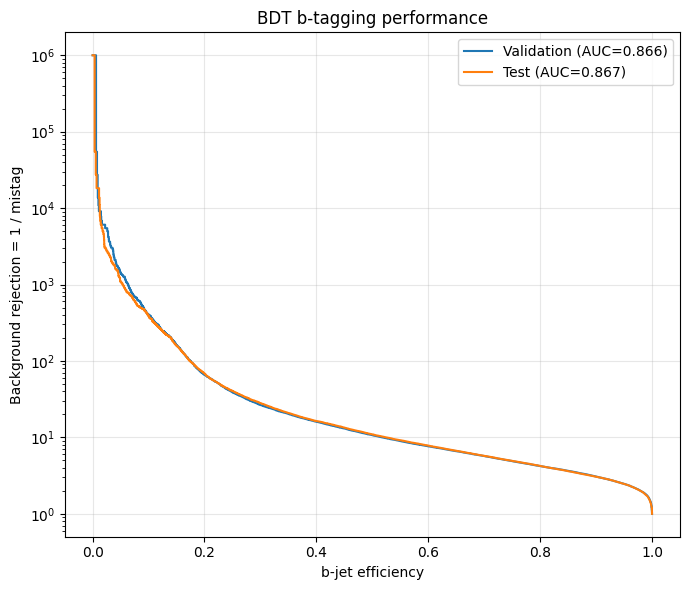

In [13]:
fpr_val, tpr_val, _ = roc_curve(y_val, val_scores)
fpr_test, tpr_test, _ = roc_curve(y_test, test_scores)

plt.figure(figsize=(7, 6))
plt.plot(tpr_val, 1.0 / np.clip(fpr_val, 1e-6, None), label=f"Validation (AUC={val_auc:.3f})")
plt.plot(tpr_test, 1.0 / np.clip(fpr_test, 1e-6, None), label=f"Test (AUC={test_auc:.3f})")
plt.yscale("log")
plt.xlabel("b-jet efficiency")
plt.ylabel("Background rejection = 1 / mistag")
plt.title("BDT b-tagging performance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

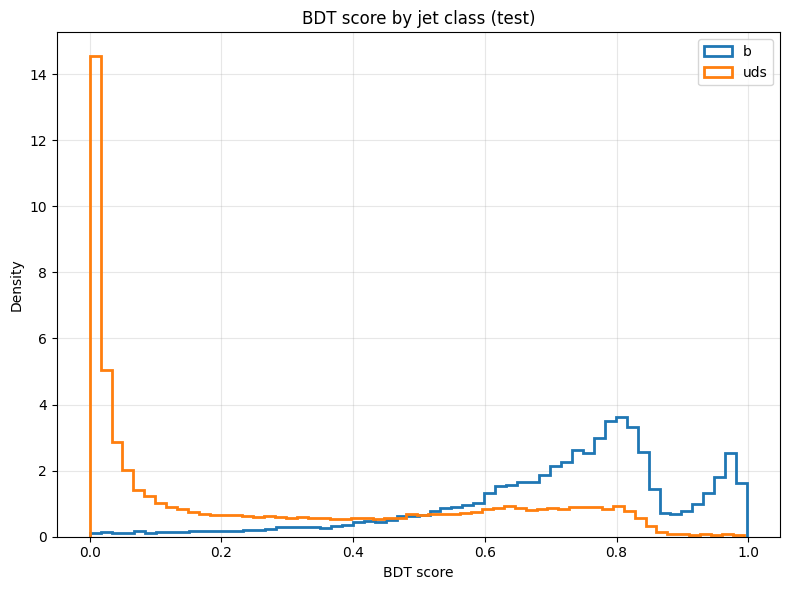

In [14]:
plot_df = test.copy()
plot_df["score_bdt"] = test_scores

plt.figure(figsize=(8, 6))
for label in ["b", "c", "g", "uds"]:
    mask = plot_df["sample_label"] == label
    if np.any(mask):
        plt.hist(
            plot_df.loc[mask, "score_bdt"],
            bins=60,
            histtype="step",
            linewidth=2,
            density=True,
            label=label,
        )

plt.xlabel("BDT score")
plt.ylabel("Density")
plt.title("BDT score by jet class (test)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

display(feat_imp.head(20))

,feature,importance
0,jet_pt,0.279852
25,max_abs_d0,0.101802
7,track_pt_sum,0.091683
30,pt_weighted_abs_d0,0.071913
5,jet_nneutral,0.048155
3,jet_mass,0.045574
31,pt_weighted_abs_dz,0.039640
24,mean_abs_d0,0.035125
26,std_abs_d0,0.029796
28,max_abs_dz,0.029086


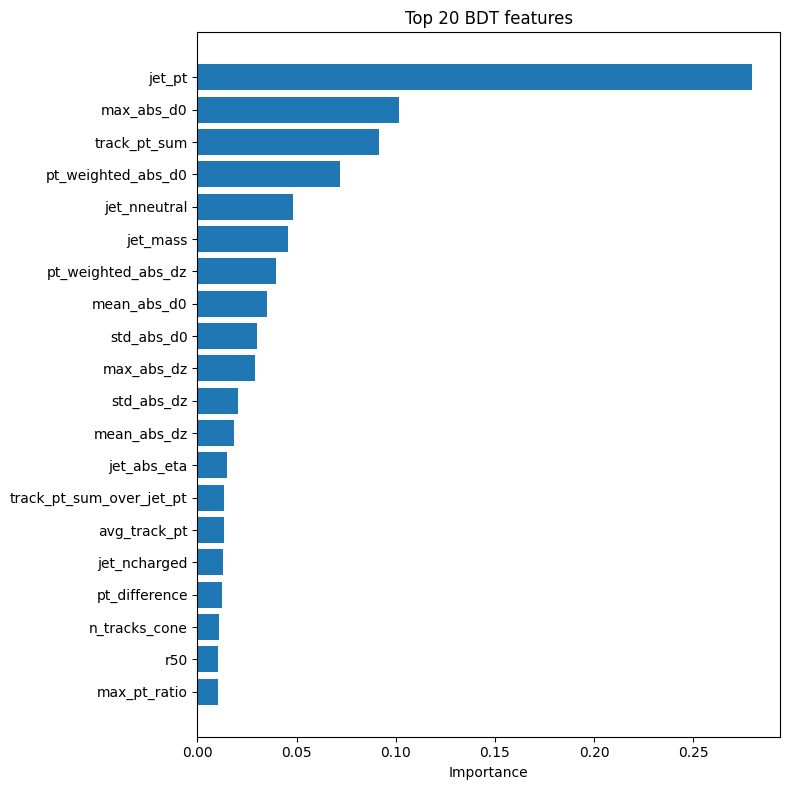

In [16]:
topk = 20

plt.figure(figsize=(8, 8))
plt.barh(feat_imp["feature"].head(topk)[::-1], feat_imp["importance"].head(topk)[::-1])
plt.xlabel("Importance")
plt.title(f"Top {topk} BDT features")
plt.tight_layout()
plt.show()

In [17]:
model.save_model(OUTPUT_DIR / "bdt_model.json")
joblib.dump(feature_cols, OUTPUT_DIR / "bdt_features.joblib")

feat_imp.to_csv(OUTPUT_DIR / "bdt_feature_importance.csv", index=False)

scores_out = test.copy()
scores_out["score_bdt"] = test_scores
scores_out.to_csv(OUTPUT_DIR / "test_scores_bdt.csv", index=False)

metrics = {
    "val_auc": float(val_auc),
    "test_auc": float(test_auc),
    "mistag_report": report,
    "n_train": int(len(train)),
    "n_val": int(len(val)),
    "n_test": int(len(test)),
    "features": feature_cols,
}

with open(OUTPUT_DIR / "bdt_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name)

Saved files:
 - bdt_feature_importance.csv
 - bdt_features.joblib
 - bdt_metrics.json
 - bdt_model.json
 - test_scores_bdt.csv


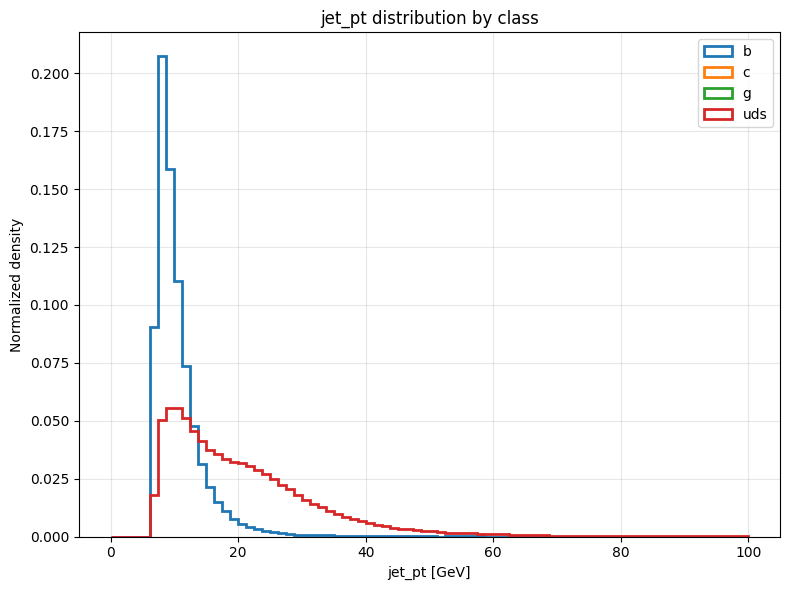

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/tonnysoyyo/btag-dataset")

train = pd.read_parquet(DATA_DIR / "train_20menos.parquet")
val   = pd.read_parquet(DATA_DIR / "val_20menos.parquet")
test  = pd.read_parquet(DATA_DIR / "test_20menos.parquet")

full_df = pd.concat([train, val, test], ignore_index=True)

plt.figure(figsize=(8,6))

for label in ["b", "c", "g", "uds"]:
    mask = full_df["sample_label"] == label
    plt.hist(
        full_df.loc[mask, "jet_pt"],
        bins=80,
        range=(0, 100),
        density=True,
        histtype="step",
        linewidth=2,
        label=label
    )

plt.xlabel("jet_pt [GeV]")
plt.ylabel("Normalized density")
plt.title("jet_pt distribution by class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()